**Extract ZIP Files**

In [ ]:
import os
import zipfile

# Define paths to the uploaded ZIP files
train_zip_path = '/content/train.zip'
test_zip_path = '/content/test.zip'
validation_zip_path = '/content/validation.zip'

# Define extraction directories
extracted_train_path = '/content/train'
extracted_test_path = '/content/test'
extracted_validation_path = '/content/validation'

# Function to extract zip files
def extract_zip(zip_path, extract_to):
    if not os.path.exists(extract_to):
        os.makedirs(extract_to)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print(f"Extracted {zip_path} to {extract_to}")

# Extract all zip files
extract_zip(train_zip_path, extracted_train_path)
extract_zip(test_zip_path, extracted_test_path)
extract_zip(validation_zip_path, extracted_validation_path)

# Check the extracted directories
print("Contents of training directory:", os.listdir(extracted_train_path)[:5])
print("Contents of testing directory:", os.listdir(extracted_test_path)[:5])
print("Contents of validation directory:", os.listdir(extracted_validation_path)[:5])



Extracted /content/train.zip to /content/train
Extracted /content/test.zip to /content/test
Extracted /content/validation.zip to /content/validation
Contents of training directory: ['train']
Contents of testing directory: ['test']
Contents of validation directory: ['validation']


**Check Directory Contents**

In [ ]:
# Check subdirectories and contents for each folder
train_subdir = os.path.join(extracted_train_path, 'train')
test_subdir = os.path.join(extracted_test_path, 'test')
validation_subdir = os.path.join(extracted_validation_path, 'validation')

def check_directory_contents(path):
    contents = os.listdir(path)
    print(f"Directory: {path}")
    print(f"Total files: {len(contents)}")
    print(f"All files: {contents}")
    return contents

train_files = check_directory_contents(train_subdir)
test_files = check_directory_contents(test_subdir)
validation_files = check_directory_contents(validation_subdir)



Directory: /content/train/train
Total files: 6
All files: ['surprise', 'neutral', 'sad', 'fear', 'angry', 'happy']
Directory: /content/test/test
Total files: 6
All files: ['surprise', 'neutral', 'sad', 'fear', 'angry', 'happy']
Directory: /content/validation/validation
Total files: 6
All files: ['surprise', 'neutral', 'sad', 'fear', 'angry', 'happy']


**Validate Image Files**

In [ ]:
from PIL import Image

def validate_images(directory):
    """
    Validates that all files in the directory are readable images.
    Returns a list of valid and invalid files.
    """
    valid_images = []
    invalid_images = []

    for root, _, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)
            try:
                with Image.open(file_path) as img:
                    img.verify()  # Check if the image is valid
                valid_images.append(file_path)
            except Exception as e:
                invalid_images.append((file_path, str(e)))

    return valid_images, invalid_images

# Validate images in each directory
valid_train_images, invalid_train_images = validate_images(train_subdir)
valid_test_images, invalid_test_images = validate_images(test_subdir)
valid_validation_images, invalid_validation_images = validate_images(validation_subdir)

# Print summary
print(f"Training set: {len(valid_train_images)} valid images, {len(invalid_train_images)} invalid images.")
print(f"Testing set: {len(valid_test_images)} valid images, {len(invalid_test_images)} invalid images.")
print(f"Validation set: {len(valid_validation_images)} valid images, {len(invalid_validation_images)} invalid images.")

# If any invalid images, list the first few
if invalid_train_images:
    print("Sample invalid training images:", invalid_train_images[:5])
if invalid_test_images:
    print("Sample invalid testing images:", invalid_test_images[:5])
if invalid_validation_images:
    print("Sample invalid validation images:", invalid_validation_images[:5])


Training set: 4999 valid images, 0 invalid images.
Testing set: 750 valid images, 0 invalid images.
Validation set: 750 valid images, 0 invalid images.


**Load Image Data**

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define transformations for data augmentation and normalization
transform = transforms.Compose([
    transforms.Resize((64, 64)),  # Resize images to a uniform size
    transforms.ToTensor(),       # Convert images to tensors
    transforms.Normalize((0.5,), (0.5,))  # Normalize pixel values to [-1, 1]
])

# Load datasets using ImageFolder
train_dataset = datasets.ImageFolder(root=train_subdir, transform=transform)
test_dataset = datasets.ImageFolder(root=test_subdir, transform=transform)
validation_dataset = datasets.ImageFolder(root=validation_subdir, transform=transform)

# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)

# Check dataset structure
print(f"Training dataset: {len(train_dataset)} images in {len(train_dataset.classes)} classes: {train_dataset.classes}")
print(f"Testing dataset: {len(test_dataset)} images in {len(test_dataset.classes)} classes: {test_dataset.classes}")
print(f"Validation dataset: {len(validation_dataset)} images in {len(validation_dataset.classes)} classes: {validation_dataset.classes}")


Training dataset: 4999 images in 6 classes: ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Testing dataset: 750 images in 6 classes: ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Validation dataset: 750 images in 6 classes: ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']


**EfficientNet Model Training**


Training Pre-trained Model (EfficientNet-B0)...
Epoch 1/36, Train Loss: 1.7876, Train Acc: 24.12%, Val Loss: 1.6495, Val Acc: 34.27%
Epoch 2/36, Train Loss: 1.6466, Train Acc: 32.23%, Val Loss: 1.6116, Val Acc: 33.33%
Epoch 3/36, Train Loss: 1.5799, Train Acc: 35.77%, Val Loss: 1.6183, Val Acc: 36.13%
Epoch 4/36, Train Loss: 1.5520, Train Acc: 37.33%, Val Loss: 1.6088, Val Acc: 34.27%
Epoch 5/36, Train Loss: 1.5005, Train Acc: 40.45%, Val Loss: 1.5979, Val Acc: 35.33%
Epoch 6/36, Train Loss: 1.4698, Train Acc: 41.75%, Val Loss: 1.6000, Val Acc: 36.13%
Epoch 7/36, Train Loss: 1.4423, Train Acc: 43.39%, Val Loss: 1.6067, Val Acc: 34.53%
Epoch 8/36, Train Loss: 1.4084, Train Acc: 44.57%, Val Loss: 1.6108, Val Acc: 35.47%
Epoch 9/36, Train Loss: 1.3731, Train Acc: 46.71%, Val Loss: 1.5919, Val Acc: 36.93%
Epoch 10/36, Train Loss: 1.3450, Train Acc: 48.31%, Val Loss: 1.5892, Val Acc: 38.53%
Epoch 11/36, Train Loss: 1.3134, Train Acc: 49.11%, Val Loss: 1.6205, Val Acc: 35.73%
Epoch 12/36, T

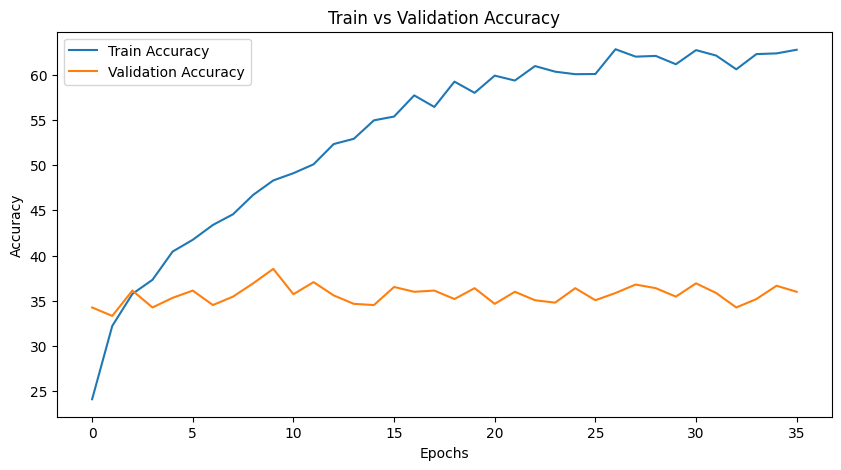

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

# Define device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pre-trained EfficientNet-B0 model
print("\nTraining Pre-trained Model (EfficientNet-B0)...")
pretrained_model = models.efficientnet_b0(pretrained=True)

# Freeze all layers
for param in pretrained_model.parameters():
    param.requires_grad = False

# Allow fine-tuning of the last feature layer
for layer in [pretrained_model.features[-1]]:  # Last group of features
    for param in layer.parameters():
        param.requires_grad = True

# Modify the final layer to fit the number of classes
num_classes = len(train_dataset.classes)
pretrained_model.classifier[1] = nn.Linear(pretrained_model.classifier[1].in_features, num_classes)

# Add a Dropout layer
pretrained_model.classifier = nn.Sequential(
    nn.Dropout(p=0.5),
    pretrained_model.classifier[1]
)

pretrained_model.to(device)

# Define loss function, optimizer, and scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, pretrained_model.parameters()),
    lr=0.0005,
    weight_decay=0.0001
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5, verbose=True)


# Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10):
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    best_loss = float("inf")

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_accuracy = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_accuracy)

        val_loss, val_accuracy = evaluate_model(model, val_loader, criterion)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_accuracy:.2f}%, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.2f}%")

        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(model.state_dict(), "best_model.pth")

        scheduler.step(val_loss)

    return train_losses, val_losses, train_accuracies, val_accuracies

# Evaluation function
def evaluate_model(model, dataloader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = running_loss / len(dataloader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

import matplotlib.pyplot as plt

# Plotting function
def plot_accuracy(train_accuracies, val_accuracies):
    plt.figure(figsize=(10, 5))
    plt.plot(train_accuracies, label='Train Accuracy')
    plt.plot(val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Train vs Validation Accuracy')
    plt.show()

# Train the model
train_losses, val_losses, train_accuracies, val_accuracies = train_model(
    pretrained_model, train_loader, validation_loader, criterion, optimizer, scheduler, num_epochs=36
)

# Plot training and validation accuracy
plot_accuracy(train_accuracies, val_accuracies)


**Display Model Predictions**

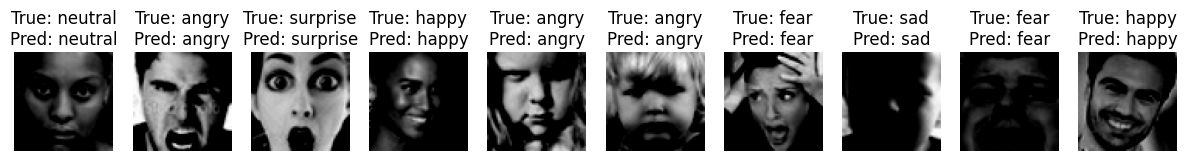

In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np
import torch

# Function to display images with true labels and predictions
def imshow(images, labels, predictions, class_names):
    """Display images with labels"""
    # Convert images to a displayable format
    images = images.numpy()
    if images.ndim == 4:  # If the images are RGB
        images = np.transpose(images, (0, 2, 3, 1))  # Change dimensions to (Batch, Height, Width, Channels)

    # Clip image values between 0 and 1
    images = np.clip(images, 0, 1)

    # Set up the plot to display images
    num_images = images.shape[0]
    fig, axes = plt.subplots(1, num_images, figsize=(15, 15))

    for i in range(num_images):
        ax = axes[i]
        ax.imshow(images[i])
        title = f"True: {class_names[labels[i]]}\nPred: {class_names[predictions[i]]}"
        ax.set_title(title)
        ax.axis('off')

    plt.show()

# Function to pick random images from the data and display them with predictions
def display_random_predictions(dataloader, model, class_names, num_images=10):
    """Display random images with predictions"""
    model.eval()  # Set the model to evaluation mode

    # Select random samples from the dataset
    dataset = dataloader.dataset
    indices = random.sample(range(len(dataset)), num_images)

    images, labels = zip(*[dataset[i] for i in indices])  # Get the images and labels
    images = torch.stack(images)  # Combine the images into one tensor
    labels = torch.tensor(labels)

    # Send images to the device (GPU or CPU)
    inputs = images.to(device)

    # Compute the predictions
    with torch.no_grad():
        outputs = model(inputs)
        _, predictions = torch.max(outputs, 1)

    # Display images with true labels and predictions
    imshow(images, labels, predictions.cpu(), class_names)
class_names = train_dataset.classes

# Call the function to display random images with predictions
display_random_predictions(train_loader, pretrained_model, class_names, num_images=10)


**Model Performance Metrics**

In [ ]:
# Function to calculate accuracy and loss for a dataset
def calculate_metrics(model, dataloader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Make predictions and calculate the loss
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            # Calculate the number of correct predictions
            _, predictions = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predictions == labels).sum().item()

    # Calculate average loss and accuracy
    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

# Function to display the loss and accuracy for the datasets
def display_metrics(model, train_loader, val_loader, test_loader, criterion):
    train_loss, train_accuracy = calculate_metrics(model, train_loader, criterion)
    print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%")

    val_loss, val_accuracy = calculate_metrics(model, val_loader, criterion)
    print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%")

    test_loss, test_accuracy = calculate_metrics(model, test_loader, criterion)
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")

# Call the function to calculate and display the metrics
display_metrics(pretrained_model, train_loader, validation_loader, test_loader, criterion)


Train Loss: 0.5684, Train Accuracy: 89.16%
Validation Loss: 1.6701, Validation Accuracy: 36.00%
Test Loss: 1.6880, Test Accuracy: 35.07%


**Confusion Matrix Metrics**

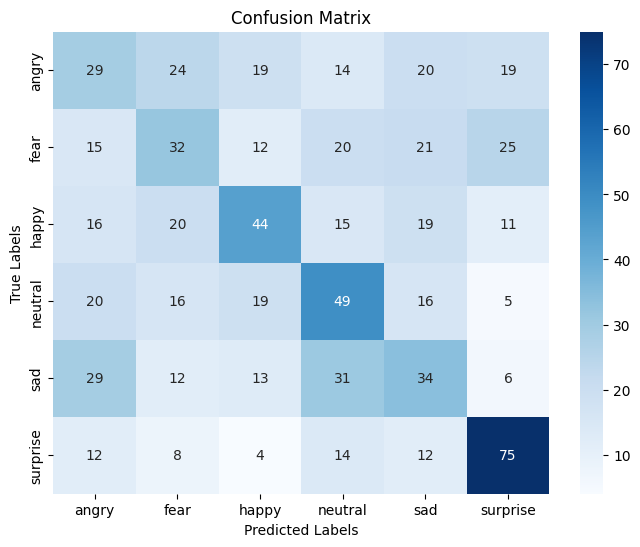

Accuracy: 0.35

Classification Report:
              precision    recall  f1-score   support

       angry       0.24      0.23      0.24       125
        fear       0.29      0.26      0.27       125
       happy       0.40      0.35      0.37       125
     neutral       0.34      0.39      0.37       125
         sad       0.28      0.27      0.28       125
    surprise       0.53      0.60      0.56       125

    accuracy                           0.35       750
   macro avg       0.35      0.35      0.35       750
weighted avg       0.35      0.35      0.35       750



In [ ]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Function to calculate and display confusion matrix and metrics
def plot_confusion_matrix_and_metrics(model, dataloader, classes, device):
    model.eval()  # Ensure model is in evaluation mode
    all_preds = []
    all_labels = []

    # Get predictions and true labels
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Plot confusion matrix using seaborn
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()

    # Calculate classification metrics
    accuracy = accuracy_score(all_labels, all_preds)
    print(f'Accuracy: {accuracy:.2f}')

    # Print classification report (includes precision, recall, F1-score)
    report = classification_report(all_labels, all_preds, target_names=classes)
    print("\nClassification Report:")
    print(report)

# Example usage
# Call the function to display the confusion matrix and metrics from the test set
plot_confusion_matrix_and_metrics(pretrained_model, test_loader, train_loader.dataset.classes, device)


In [ ]:
torch.save(pretrained_model.state_dict(), 'model_weights.pth')


**Image Emotion Prediction**

The image at /content/download.jpg belongs to class: angry


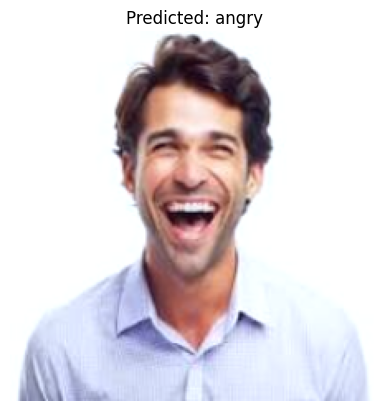

The image at /content/download (1).jpg belongs to class: angry


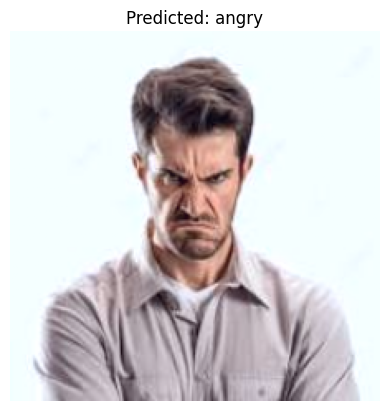

In [ ]:
import torch
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torchvision import models
import torch.nn as nn

# Define the transformation (same as used for training)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Define your model (e.g., EfficientNet or any pretrained model)
model = models.efficientnet_b0(pretrained=True)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 6)  # Update the last layer for 6 classes
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Function to predict a list of images
def predict_images(image_paths, model, transform, class_names, device):
    model.eval()  # Set the model to evaluation mode

    for image_path in image_paths:
        # Load the image
        image = Image.open(image_path)

        # Apply transformations
        image_tensor = transform(image).unsqueeze(0).to(device)  # Add batch dimension and send to device

        # Make the prediction
        with torch.no_grad():
            outputs = model(image_tensor)
            _, predicted = torch.max(outputs, 1)

        # Get the predicted class
        predicted_class = class_names[predicted.item()]
        print(f"The image at {image_path} belongs to class: {predicted_class}")

        # Display the image with the predicted class
        image = image_tensor.squeeze(0).cpu().numpy().transpose(1, 2, 0)  # Remove batch dimension and convert to numpy
        image = (image * 0.229 + 0.485)  # Undo normalization for display
        image = np.clip(image, 0, 1)  # Ensure values are between 0 and 1
        plt.imshow(image)
        plt.title(f"Predicted: {predicted_class}")
        plt.axis('off')
        plt.show()

# Example usage:
image_paths = ['/content/download.jpg', '/content/download (1).jpg']  # List of image paths
class_names = ['fear', 'neutral', 'sad', 'surprise', 'happy', 'angry']  # Emotion classes
predict_images(image_paths, model, transform, class_names, device)
